<a href="https://colab.research.google.com/github/merugumallarajasimha/deep_learning_basics/blob/main/ann_with_regularization_weightinitialization_BatchNormalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", data.target_names)

X shape: (569, 30)
y shape: (569,)
Classes: ['malignant' 'benign']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training mean:", X_train.mean())
print("Training std:", X_train.std())

Training mean: -1.145197083276352e-16
Training std: 1.0


In [6]:
tf.keras.backend.clear_session()

baseline_model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7830 - loss: 0.5277 - val_accuracy: 0.9451 - val_loss: 0.3236
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9368 - loss: 0.2277 - val_accuracy: 0.9560 - val_loss: 0.1604
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9560 - loss: 0.1254 - val_accuracy: 0.9780 - val_loss: 0.0974
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9753 - loss: 0.0860 - val_accuracy: 0.9780 - val_loss: 0.0712
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9753 - loss: 0.0716 - val_accuracy: 0.9780 - val_loss: 0.0534
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9835 - loss: 0.0603 - val_accuracy: 0.9890 - val_loss: 0.0447
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9835 - loss: 0.0536 - val_accuracy: 0.9890 - val_loss: 0.0422
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9890 - loss: 0.0455 - val_accuracy: 0.

In [9]:
baseline_loss, baseline_accuracy = baseline_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Baseline Test Loss:", baseline_loss)
print("Baseline Test Accuracy:", baseline_accuracy)

Baseline Test Loss: 0.22517478466033936
Baseline Test Accuracy: 0.9561403393745422


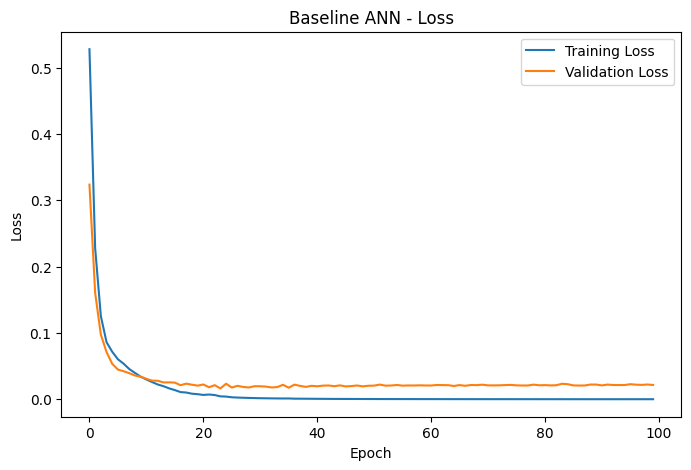

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline ANN - Loss')
plt.legend()

plt.show()

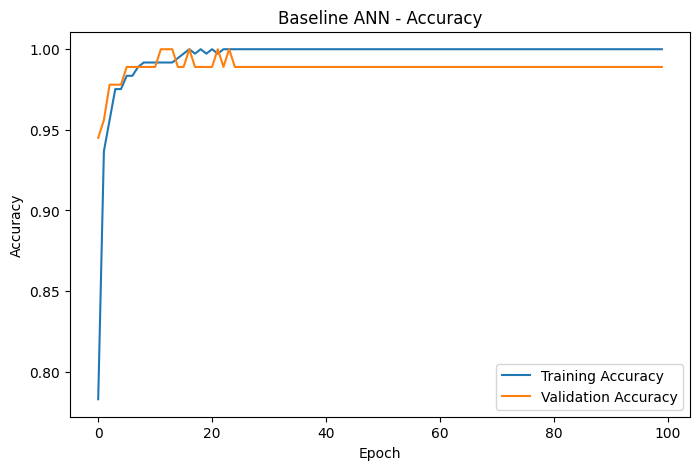

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Baseline ANN - Accuracy')
plt.legend()

plt.show()

In [12]:
tf.keras.backend.clear_session()

improved_model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(
        128,
        kernel_initializer=HeNormal(),
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.3),

    Dense(
        64,
        kernel_initializer=HeNormal(),
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.3),

    Dense(
        32,
        kernel_initializer=HeNormal(),
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.2),

    Dense(
        1,
        activation='sigmoid'
    )
])

improved_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
improved_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [15]:
history_improved = improved_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.6923 - loss: 0.6010 - val_accuracy: 0.9451 - val_loss: 0.2462
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8846 - loss: 0.3145 - val_accuracy: 0.9451 - val_loss: 0.1948
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9176 - loss: 0.2357 - val_accuracy: 0.9451 - val_loss: 0.1656
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9176 - loss: 0.2134 - val_accuracy: 0.9560 - val_loss: 0.1429
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9396 - loss: 0.2032 - val_accuracy: 0.9560 - val_loss: 0.1286
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9533 - loss: 0.1525 - val_accuracy: 0.9670 - val_loss: 0.1148
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9505 - loss: 0.1601 - val_accuracy: 0.9670 - val_loss: 0.1023
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9505 - loss: 0.1538 - val_accuracy: 0.9780 

In [16]:
improved_loss, improved_accuracy = improved_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Improved Test Loss:", improved_loss)
print("Improved Test Accuracy:", improved_accuracy)

Improved Test Loss: 0.10800538212060928
Improved Test Accuracy: 0.9561403393745422


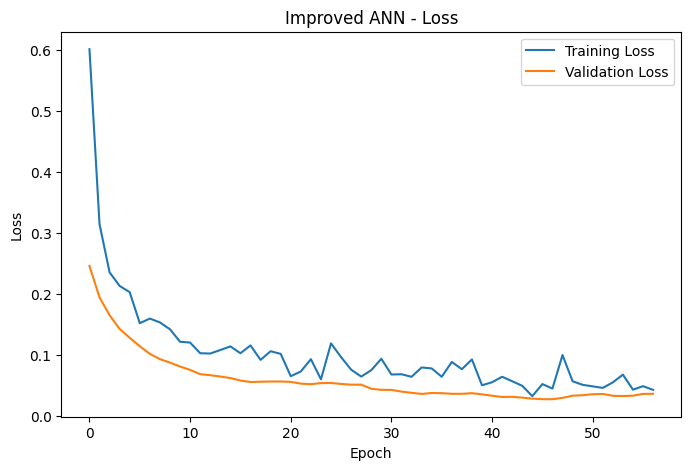

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history_improved.history['loss'], label='Training Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Improved ANN - Loss')
plt.legend()

plt.show()

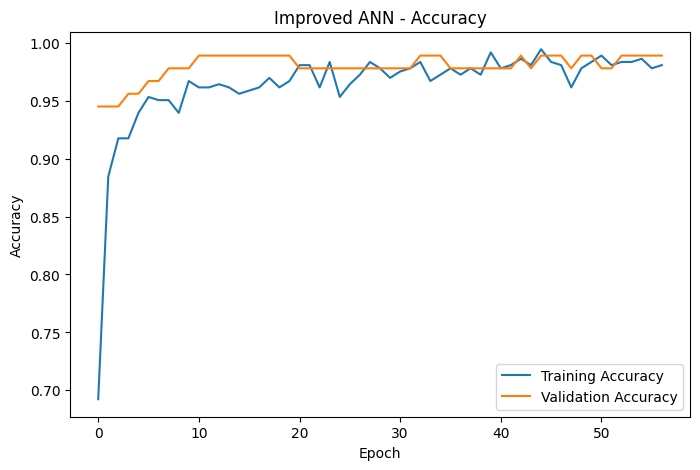

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history_improved.history['accuracy'], label='Training Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Improved ANN - Accuracy')
plt.legend()

plt.show()

In [19]:
comparison = pd.DataFrame({
    'Model': ['Baseline ANN', 'Improved ANN'],
    'Test Loss': [baseline_loss, improved_loss],
    'Test Accuracy': [baseline_accuracy, improved_accuracy]
})

comparison

,Model,Test Loss,Test Accuracy
0,Baseline ANN,0.225175,0.95614
1,Improved ANN,0.108005,0.95614
